Tahap ini digunakan untuk menghubungkan Google Colab dengan Google Drive agar dataset dapat diakses selama proses analisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tahap ini mengimpor seluruh library yang dibutuhkan untuk analisis data, visualisasi, pemodelan machine learning, dan evaluasi model.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

Tahap ini digunakan untuk membaca dataset Google Play Store ke dalam DataFrame.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/googleplaystore.csv')

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Tahap ini digunakan untuk memahami struktur dataset seperti jumlah data, jumlah atribut, dan tipe data.

In [ ]:
print("Ukuran Dataset :", df.shape)

df.info()

Ukuran Dataset : (10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


Karena penelitian berfokus pada game mobile, maka hanya data dengan kategori GAME yang digunakan.

In [ ]:
game_df = df[df['Category'] == 'GAME']

print("Jumlah Data Game :", game_df.shape)

Jumlah Data Game : (1144, 13)


Tahap ini digunakan untuk melihat karakteristik umum dari data numerik.

In [ ]:
game_df.describe()

,Rating
count,1097.000000
mean,4.286326
std,0.365375
min,1.000000
25%,4.100000
50%,4.400000
75%,4.500000
max,5.000000


Visualisasi ini menunjukkan sebaran rating game pada dataset.

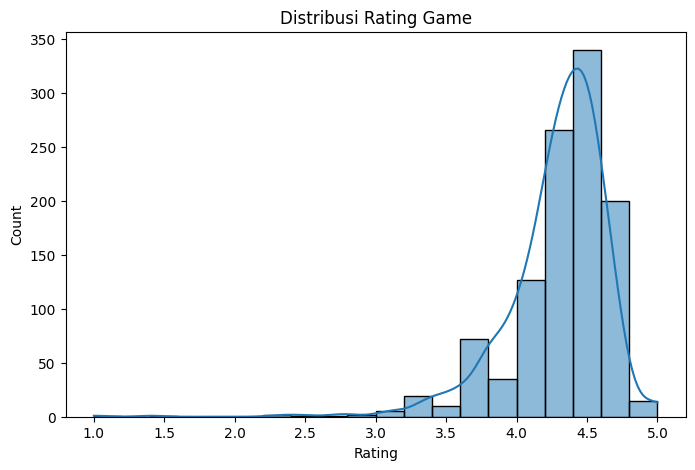

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    game_df['Rating'],
    bins=20,
    kde=True
)

plt.title('Distribusi Rating Game')
plt.show()

Tahap ini membersihkan data dan mengubah atribut ke format numerik.

In [ ]:
game_df = game_df.copy()

game_df['Installs'] = game_df['Installs'].str.replace('+','')
game_df['Installs'] = game_df['Installs'].str.replace(',','')

game_df['Installs'] = pd.to_numeric(
    game_df['Installs'],
    errors='coerce'
)

game_df['Reviews'] = pd.to_numeric(
    game_df['Reviews'],
    errors='coerce'
)

game_df['Rating'] = pd.to_numeric(
    game_df['Rating'],
    errors='coerce'
)

game_df.dropna(inplace=True)

Game dengan jumlah instalasi minimal 1 juta kali dikategorikan sebagai populer.

In [ ]:
game_df['Popularity'] = np.where(
    game_df['Installs'] >= 1000000,
    1,
    0
)

game_df['Popularity'].value_counts()

,count
Popularity,
1,737
0,360


Visualisasi ini menunjukkan jumlah game populer dan tidak populer.

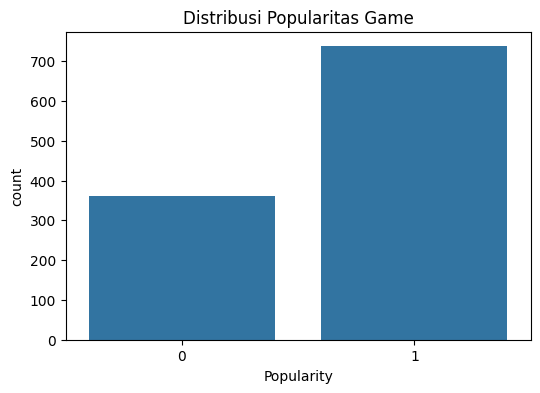

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=game_df['Popularity']
)

plt.title('Distribusi Popularitas Game')
plt.show()

Tahap ini memilih atribut yang digunakan sebagai fitur prediksi.

In [ ]:
X = game_df[['Rating','Reviews']]

y = game_df['Popularity']

Dataset dibagi menjadi data latih dan data uji.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Tahap ini melatih model Decision Tree.

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train,y_train)

dt_pred = dt_model.predict(X_test)

Tahap ini mengevaluasi performa model Decision Tree.

In [ ]:
print("Accuracy :",
      accuracy_score(y_test,dt_pred))

print(classification_report(
    y_test,
    dt_pred
))

Accuracy : 0.9363636363636364
              precision    recall  f1-score   support

           0       0.83      0.97      0.89        61
           1       0.99      0.92      0.95       159

    accuracy                           0.94       220
   macro avg       0.91      0.95      0.92       220
weighted avg       0.94      0.94      0.94       220



Visualisasi ini menunjukkan hasil prediksi benar dan salah dari model Decision Tree.

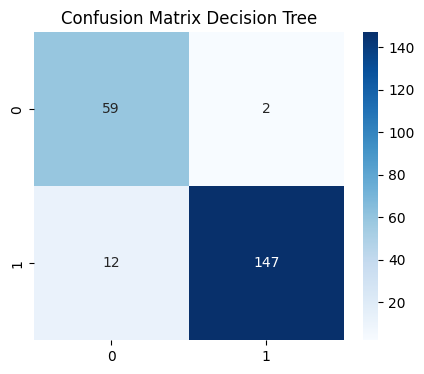

In [ ]:
cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Decision Tree')
plt.show()

Tahap ini melatih model Random Forest sebagai algoritma pembanding.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

Tahap ini mengevaluasi performa model Random Forest.

In [ ]:
print("Accuracy :",
      accuracy_score(y_test,rf_pred))

print(classification_report(
    y_test,
    rf_pred
))

Accuracy : 0.9545454545454546
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        61
           1       0.98      0.96      0.97       159

    accuracy                           0.95       220
   macro avg       0.94      0.95      0.94       220
weighted avg       0.96      0.95      0.95       220



Visualisasi ini menunjukkan hasil prediksi benar dan salah dari model Random Forest.

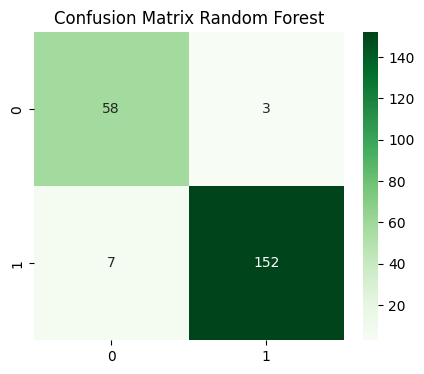

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix Random Forest')
plt.show()

Tahap ini membandingkan performa kedua algoritma berdasarkan nilai akurasi.

In [ ]:
dt_acc = accuracy_score(
    y_test,
    dt_pred
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

comparison = pd.DataFrame({
    'Model':['Decision Tree',
             'Random Forest'],
    'Accuracy':[dt_acc,
                rf_acc]
})

comparison

,Model,Accuracy
0,Decision Tree,0.936364
1,Random Forest,0.954545


Visualisasi ini digunakan untuk melihat algoritma dengan performa terbaik.

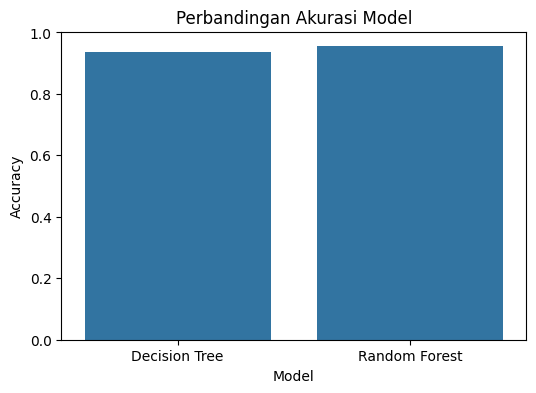

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Perbandingan Akurasi Model')

plt.show()

Tahap ini menyimpan model terbaik untuk digunakan pada aplikasi Streamlit dan deployment Hugging Face.

In [ ]:
import pickle

pickle.dump(
    rf_model,
    open('model_popularitas_game.pkl','wb')
)

Tahap ini menyimpan dataset yang telah diproses untuk kebutuhan deployment.

In [ ]:
game_df.to_csv(
    'game_clean.csv',
    index=False
)

In [ ]:
import pickle

with open('model_popularitas_game.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
import gradio as gr
import pickle
import numpy as np

# Load model
with open("model_popularitas_game.pkl", "rb") as file:
    model = pickle.load(file)

def prediksi_popularitas(rating, reviews):

    data = np.array([[rating, reviews]])

    hasil = model.predict(data)

    if hasil[0] == 1:
        return "Game Diprediksi Populer"
    else:
        return "Game Diprediksi Tidak Populer"

app = gr.Interface(
    fn=prediksi_popularitas,

    inputs=[
        gr.Number(label="Rating Game"),
        gr.Number(label="Jumlah Reviews")
    ],

    outputs=gr.Textbox(label="Hasil Prediksi"),

    title="Prediksi Popularitas Game Mobile",

    description="""
    Aplikasi Machine Learning untuk memprediksi popularitas game mobile
    berdasarkan nilai rating dan jumlah reviews menggunakan algoritma Random Forest.
    """
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://761578a0a3a4700849.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
